In [1]:
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

In [3]:
# Load the dataset
df = pd.read_csv("/content/insurance_compiled_data.csv")

# Convert date column
df['Date'] = pd.to_datetime(df['Date']) #to use for trend of reviews overtime

# Check for missing values
print(df.isnull().sum())

Date          5000
Author        5007
Body          5000
Heading       5002
Rating        5000
Location      5000
Brand_Name       0
dtype: int64


In [4]:
#drop the null values
df.dropna(inplace=True)
print(f"The null values for each column after dropping is: {df.isnull().sum()}")

The null values for each column after dropping is: Date          0
Author        0
Body          0
Heading       0
Rating        0
Location      0
Brand_Name    0
dtype: int64


In [5]:
#check for duplicates
df.duplicated().sum()

np.int64(0)

In [6]:
df.head()

,Date,Author,Body,Heading,Rating,Location,Brand_Name
0,2023-11-21,R&N,David and Andrew formed a dynamic team that we...,Exceptional experience,5.0,GB,FirstMortgage
1,2024-07-26,Lynsey,A few months ago i had my first appointment wi...,A few months ago i had my first…,5.0,GB,FirstMortgage
2,2022-06-27,Mairi-Anne Maclennan,I cannot recommend First Mortgage highly enoug...,Fantastic service from Paul & Donna (Glasgow),5.0,GB,FirstMortgage
3,2021-02-16,gordon scott,John and in turn Joanne worked well to make th...,Professional and seamless,5.0,GB,FirstMortgage
4,2017-04-24,Linsay Chalmers,Bobbie at First Mortgage in Corstorphine has h...,Bobbie at First Mortgage in Corstorphine,5.0,GB,FirstMortgage


**EXPLORATORY DATA ANALYSIS**

In [ ]:
df.columns

Index(['Date', 'Author', 'Body', 'Heading', 'Rating', 'Location',
       'Brand_Name'],
      dtype='object')

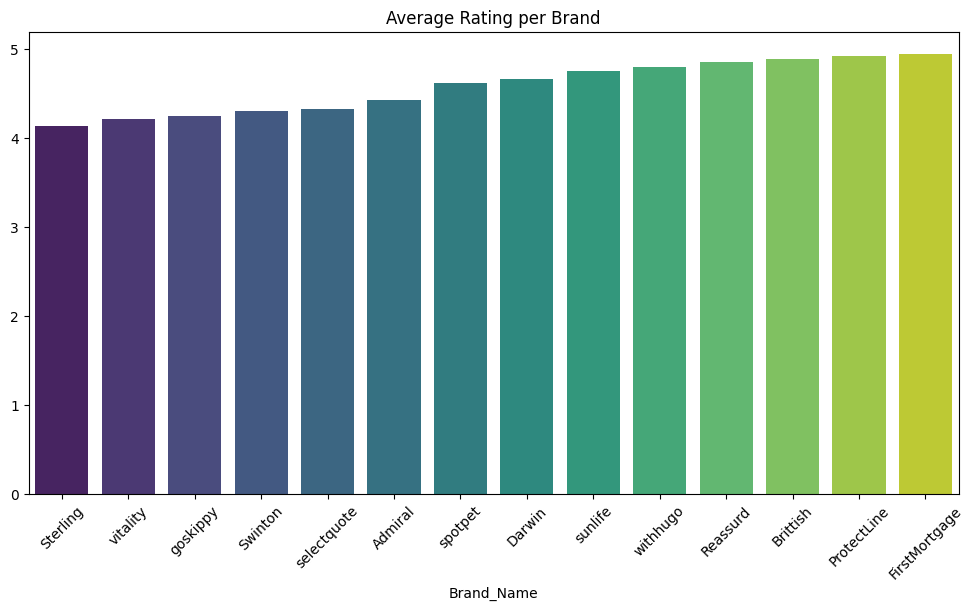

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Average rating per brand
avg_rating = df.groupby('Brand_Name')['Rating'].mean().sort_values()
plt.figure(figsize=(12,6))
sns.barplot(x=avg_rating.index, y=avg_rating.values, palette='viridis')
plt.xticks(rotation=45)
plt.title('Average Rating per Brand')
plt.show()

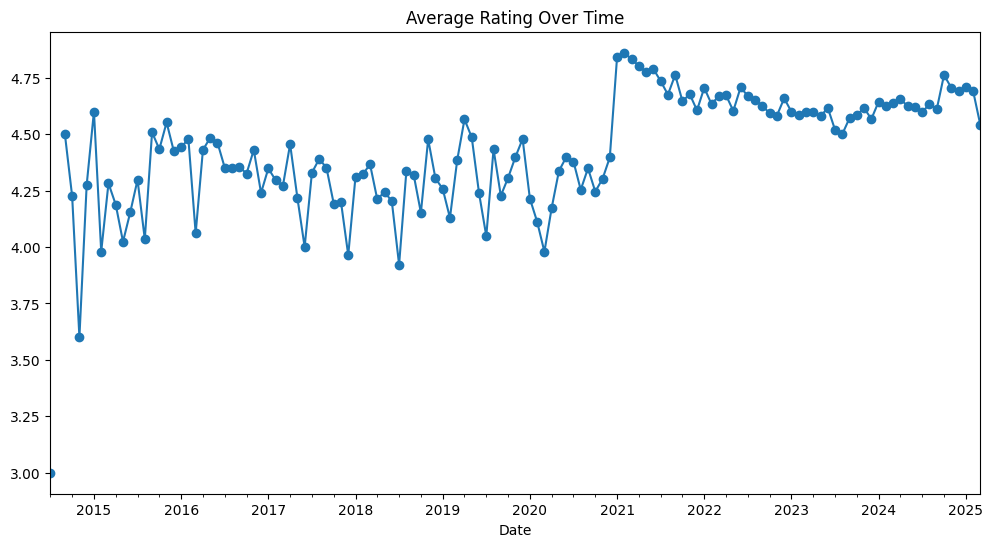

In [ ]:
# Rating trend over time
df.set_index('Date', inplace=True)
df.resample('M')['Rating'].mean().plot(figsize=(12,6), marker='o', title="Average Rating Over Time")
plt.show()

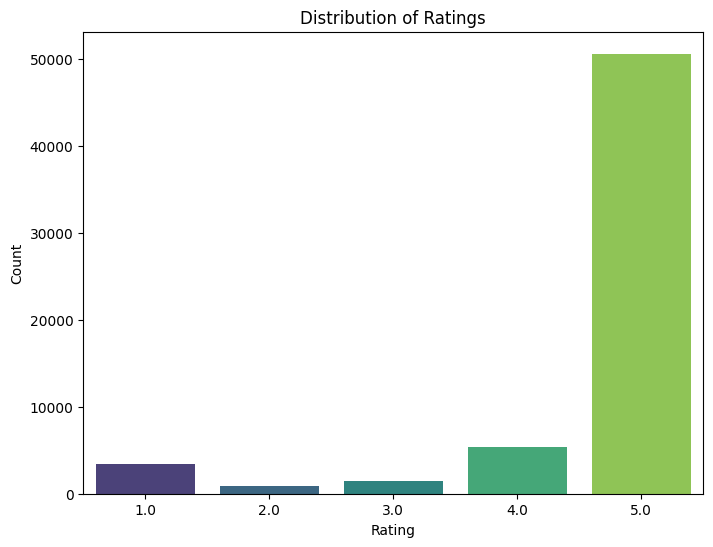

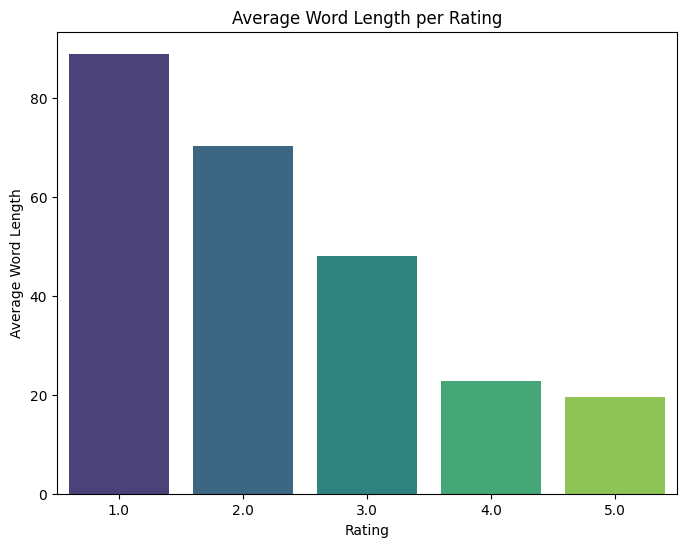

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Distribution of Ratings
plt.figure(figsize=(8, 6))
sns.countplot(x='Rating', data=df, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


# Average Word Length per Rating
df['Word_Count'] = df['Body'].apply(lambda text: len(text.split()))
average_word_length = df.groupby('Rating')['Word_Count'].mean()

plt.figure(figsize=(8, 6))
sns.barplot(x=average_word_length.index, y=average_word_length.values, palette='viridis')
plt.title('Average Word Length per Rating')
plt.xlabel('Rating')
plt.ylabel('Average Word Length')
plt.show()

**DATA PREPROCESSING**

In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Download NLTK resources if not already installed
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab') # Download the punkt_tab data for sentence tokenization

# Initialize stopwords and lemmatizer
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\W', ' ', text)  # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra spaces
    tokens = word_tokenize(text)  # Tokenization
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]  # Remove stopwords & lemmatize
    return " ".join(tokens)

# Apply preprocessing
df['Cleaned_Review'] = df['Body'].apply(preprocess_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
df["Cleaned_Review"].head()

,Cleaned_Review
Date,
2023-11-21,david andrew formed dynamic team went beyond s...
2024-07-26,month ago first appointment kenny branch leith...
2022-06-27,recommend first mortgage highly enough paul do...
2021-02-16,john turn joanne worked well make whole proces...
2017-04-24,bobbie first mortgage corstorphine helped appl...


**TEXT CLASSIFICATION**

In [ ]:
!pip install vaderSentiment

In [ ]:
!pip install textblob

In [ ]:
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# TextBlob Sentiment Classification
def classify_textblob(text):
    polarity = TextBlob(text).sentiment.polarity
    return "Positive" if polarity > 0 else "Negative" if polarity < 0 else "Neutral"

# VADER Sentiment Classification
analyzer = SentimentIntensityAnalyzer()
def classify_vader(text):
    score = analyzer.polarity_scores(text)['compound']
    return "Positive" if score > 0.05 else "Negative" if score < -0.05 else "Neutral"

# Apply both methods
df['TextBlob_Sentiment'] = df['Cleaned_Review'].apply(classify_textblob)
df['VADER_Sentiment'] = df['Cleaned_Review'].apply(classify_vader)

# Compare methods
print(df[['Cleaned_Review', 'TextBlob_Sentiment', 'VADER_Sentiment']].head(10))


                                               Cleaned_Review  \
Date                                                            
2023-11-21  david andrew formed dynamic team went beyond s...   
2024-07-26  month ago first appointment kenny branch leith...   
2022-06-27  recommend first mortgage highly enough paul do...   
2021-02-16  john turn joanne worked well make whole proces...   
2017-04-24  bobbie first mortgage corstorphine helped appl...   
2022-06-22  chris debbi found best deal helped secure good...   
2021-02-25                                      great service   
2022-10-06  recently offered mortgage first time buyer fir...   
2020-03-06  excellent impartial service plenty time discus...   
2018-10-15  experience first mortgage excellent first time...   

           TextBlob_Sentiment VADER_Sentiment  
Date                                           
2023-11-21           Positive        Positive  
2024-07-26           Positive        Positive  
2022-06-27           Positi

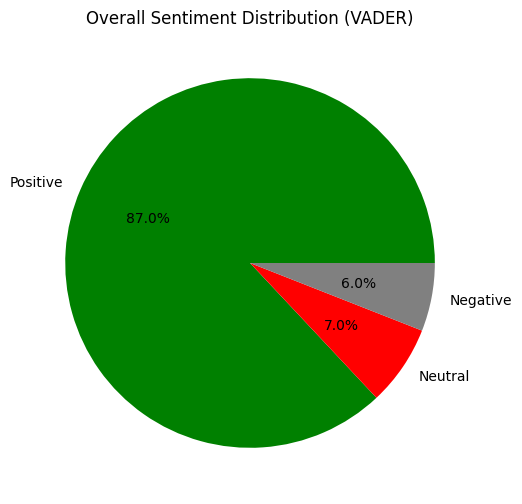

In [ ]:
import matplotlib.pyplot as plt

# Count the number of reviews per sentiment
sentiment_counts = df['VADER_Sentiment'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['green', 'red', 'gray'])
plt.title("Overall Sentiment Distribution (VADER)")
plt.show()


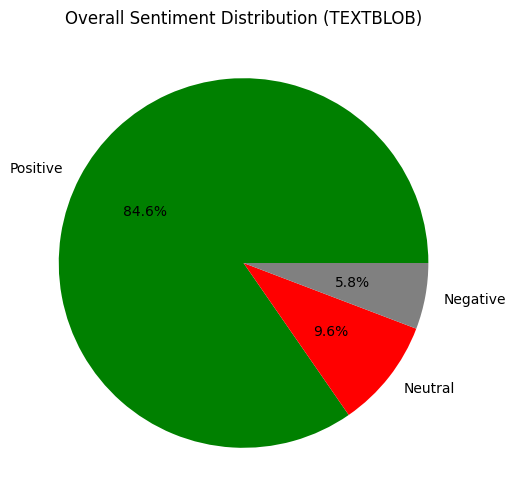

In [ ]:
# Count the number of reviews per sentiment
sentiment_counts = df['TextBlob_Sentiment'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['green', 'red', 'gray'])
plt.title("Overall Sentiment Distribution (TEXTBLOB)")
plt.show()

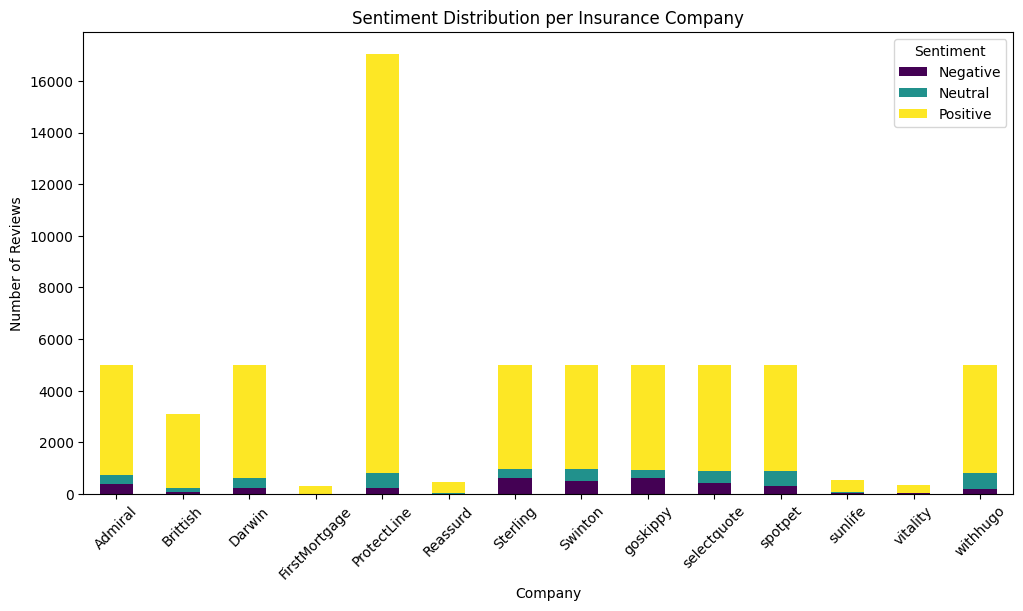

In [ ]:
import seaborn as sns

# Count sentiment per company
company_sentiment = df.groupby('Brand_Name')['VADER_Sentiment'].value_counts().unstack()

# Stacked bar plot
company_sentiment.plot(kind='bar', stacked=True, figsize=(12,6), colormap='viridis')
plt.xticks(rotation=45)
plt.title('Sentiment Distribution per Insurance Company')
plt.xlabel('Company')
plt.ylabel('Number of Reviews')
plt.legend(title="Sentiment")
plt.show()

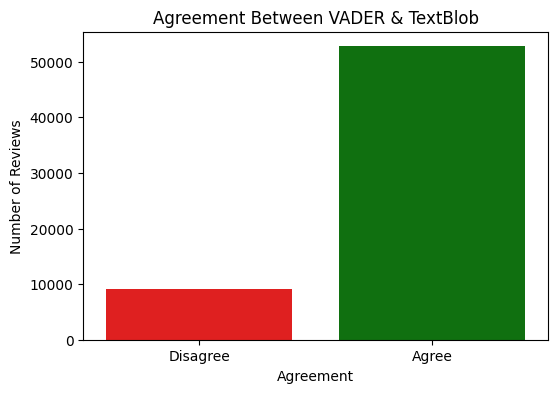

In [ ]:
# Compare VADER & TextBlob
df['Agreement'] = df['VADER_Sentiment'] == df['TextBlob_Sentiment']

# Count agreements and disagreements
agreement_counts = df['Agreement'].value_counts()

# Bar plot
plt.figure(figsize=(6,4))
sns.barplot(x=agreement_counts.index, y=agreement_counts.values, palette=['red', 'green'])
plt.xticks([0,1], ['Disagree', 'Agree'])
plt.ylabel("Number of Reviews")
plt.title("Agreement Between VADER & TextBlob")
plt.show()

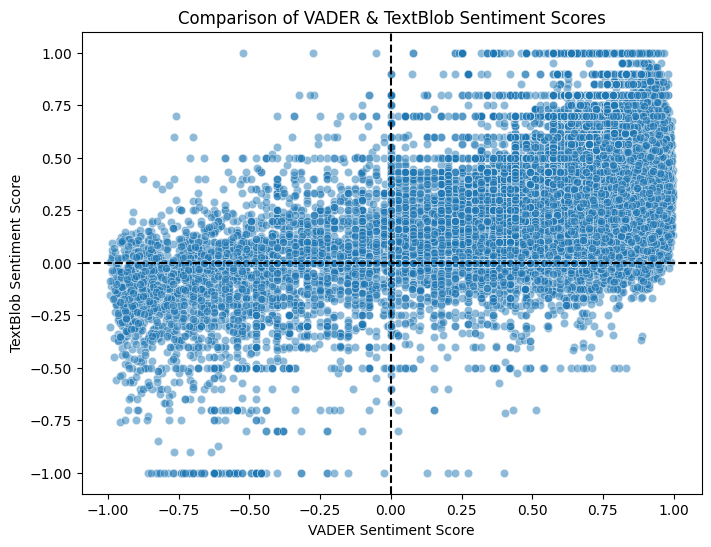

In [ ]:
df['VADER_Score'] = df['Cleaned_Review'].apply(lambda x: analyzer.polarity_scores(x)['compound'])
df['TextBlob_Score'] = df['Cleaned_Review'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['VADER_Score'], y=df['TextBlob_Score'], alpha=0.5)
plt.xlabel("VADER Sentiment Score")
plt.ylabel("TextBlob Sentiment Score")
plt.title("Comparison of VADER & TextBlob Sentiment Scores")
plt.axhline(0, color='black', linestyle='dashed')
plt.axvline(0, color='black', linestyle='dashed')
plt.show()


In [ ]:
correlation_vader = df[['VADER_Score', 'Rating']].corr().iloc[0,1]
correlation_textblob = df[['TextBlob_Score', 'Rating']].corr().iloc[0,1]

print(f"Correlation between VADER Score and Ratings: {correlation_vader:.2f}")
print(f"Correlation between TextBlob Score and Ratings: {correlation_textblob:.2f}")


Correlation between VADER Score and Ratings: 0.52
Correlation between TextBlob Score and Ratings: 0.41


In [ ]:
df.columns

Index(['Author', 'Body', 'Heading', 'Rating', 'Location', 'Brand_Name',
       'Word_Count', 'Cleaned_Review', 'TextBlob_Sentiment', 'VADER_Sentiment',
       'Agreement', 'VADER_Score', 'TextBlob_Score'],
      dtype='object')

**BRAND RANK SCORE**

In [ ]:
def calculate_brs(df, company_name):
    company_df = df[df['Brand_Name'] == company_name]

    total_reviews = len(company_df)
    positive_reviews = len(company_df[company_df['VADER_Sentiment'] == 'Positive'])
    negative_reviews = len(company_df[company_df['VADER_Sentiment'] == 'Negative'])

    # Compute sentiment percentages
    P = positive_reviews / total_reviews
    N = negative_reviews / total_reviews

    # Compute average rating
    avg_rating = company_df['Rating'].mean()

    # Apply BRS formula
    BRS = 50 + (P - N) * 40 + ((avg_rating - 5) / 5) * 10

    return round(BRS, 2)

# Compute BRS for all companies
df['BRS'] = df['Brand_Name'].apply(lambda x: calculate_brs(df, x))

# Display top-ranked companies by BRS
df[['Brand_Name', 'BRS']].drop_duplicates().sort_values(by="BRS", ascending=False)

,Brand_Name,BRS
Date,,
2023-11-21,FirstMortgage,88.00
2021-08-20,ProtectLine,87.33
2025-01-11,Brittish,85.60
2018-01-10,Reassurd,85.43
2022-06-29,Darwin,82.55
2024-10-17,sunlife,82.12
2024-11-09,withhugo,81.62
2024-09-04,Admiral,80.03
2021-11-09,spotpet,79.62


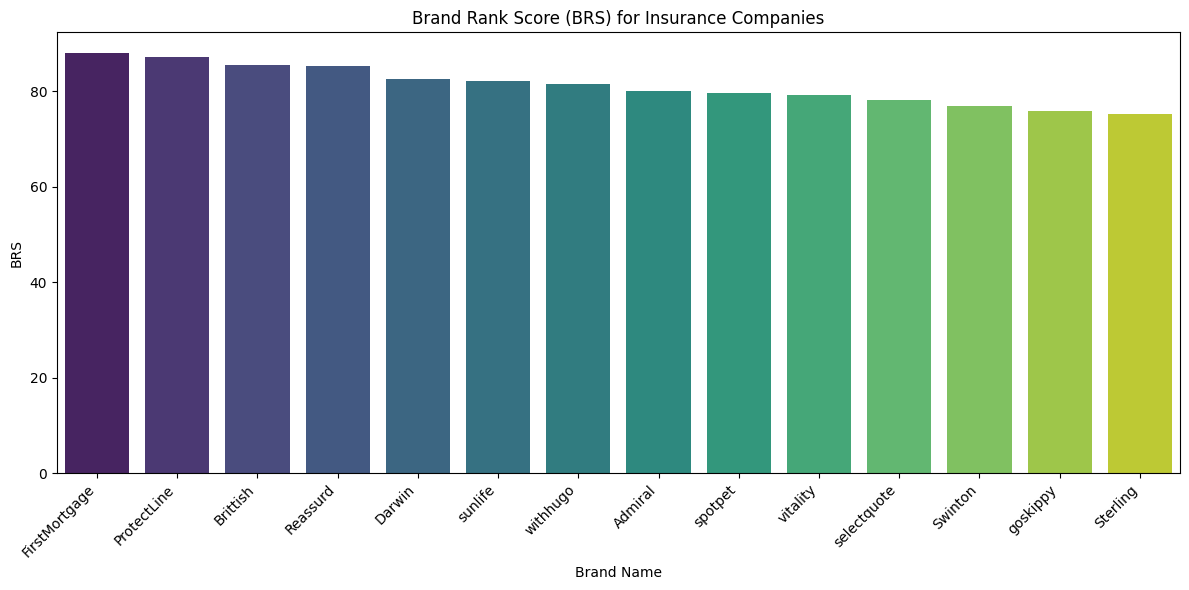

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming you have already calculated the BRS and it's stored in the 'BRS' column of your DataFrame 'df'

# Sort DataFrame by BRS in descending order
brs_df = df[['Brand_Name', 'BRS']].drop_duplicates().sort_values(by="BRS", ascending=False)

# Create bar chart
plt.figure(figsize=(12, 6))  # Adjust figure size as needed
sns.barplot(x='Brand_Name', y='BRS', data=brs_df, palette='viridis')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.title('Brand Rank Score (BRS) for Insurance Companies')
plt.xlabel('Brand Name')
plt.ylabel('BRS')
plt.tight_layout()  # Adjust layout to prevent labels from overlapping
plt.show()

**SUPERVISED LEARNING SECTION**

In [ ]:
# Define a function to classify ratings into sentiment categories
def classify_rating(rating):
    if rating <= 2:
        return 'Negative'  # 0
    elif rating == 3:
        return 'Neutral'   # 1
    else:
        return 'Positive'  # 2

# Apply the function to create a new column
df['Reclassified_Sentiment'] = df['Rating'].apply(classify_rating)

# Display counts of each sentiment category
print(df['Reclassified_Sentiment'].value_counts())

# Optional: Convert to numerical values (useful for ML)
df['Reclassified'] = df['Reclassified_Sentiment'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})


Reclassified_Sentiment
Positive    56040
Negative     4292
Neutral      1465
Name: count, dtype: int64


In [ ]:
df.columns

Index(['Author', 'Body', 'Heading', 'Rating', 'Location', 'Brand_Name',
       'Word_Count', 'Cleaned_Review', 'TextBlob_Sentiment', 'VADER_Sentiment',
       'Agreement', 'VADER_Score', 'TextBlob_Score', 'BRS',
       'Reclassified_Sentiment', 'Reclassified'],
      dtype='object')

In [ ]:
df.head()

,Author,Body,Heading,Rating,Location,Brand_Name,Word_Count,Cleaned_Review,TextBlob_Sentiment,VADER_Sentiment,Agreement,VADER_Score,TextBlob_Score,BRS,Reclassified_Sentiment,Reclassified
Date,,,,,,,,,,,,,,,,
2023-11-21,R&N,David and Andrew formed a dynamic team that we...,Exceptional experience,5.0,GB,FirstMortgage,101,david andrew formed dynamic team went beyond s...,Positive,Positive,True,0.9841,0.389722,88.0,Positive,2
2024-07-26,Lynsey,A few months ago i had my first appointment wi...,A few months ago i had my first…,5.0,GB,FirstMortgage,72,month ago first appointment kenny branch leith...,Positive,Positive,True,0.8655,0.244286,88.0,Positive,2
2022-06-27,Mairi-Anne Maclennan,I cannot recommend First Mortgage highly enoug...,Fantastic service from Paul & Donna (Glasgow),5.0,GB,FirstMortgage,91,recommend first mortgage highly enough paul do...,Positive,Positive,True,0.9842,0.231944,88.0,Positive,2
2021-02-16,gordon scott,John and in turn Joanne worked well to make th...,Professional and seamless,5.0,GB,FirstMortgage,40,john turn joanne worked well make whole proces...,Positive,Positive,True,0.9001,0.233333,88.0,Positive,2
2017-04-24,Linsay Chalmers,Bobbie at First Mortgage in Corstorphine has h...,Bobbie at First Mortgage in Corstorphine,5.0,GB,FirstMortgage,55,bobbie first mortgage corstorphine helped appl...,Positive,Positive,True,0.8553,0.187500,88.0,Positive,2


In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import nltk
import re
from nltk.sentiment import SentimentIntensityAnalyzer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder



# Tokenization & Padding
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")  # Only keep top 5000 words
tokenizer.fit_on_texts(df['Cleaned_Review'])
sequences = tokenizer.texts_to_sequences(df['Cleaned_Review'])
padded_sequences = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

# Convert target variable to numerical using LabelEncoder
label_encoder = LabelEncoder()
df['VADER_Sentiment_Encoded'] = label_encoder.fit_transform(df['VADER_Sentiment'])

# Splitting data into train and test sets
# Now use the encoded target variable
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, df['VADER_Sentiment_Encoded'], test_size=0.2, random_state=42, stratify=df['VADER_Sentiment_Encoded'])
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)  # Validation set for overfitting check

# Build the LSTM Model
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 classes: Positive, Neutral, Negative
])

# Compile the Model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the Model
history = model.fit(X_train, y_train, epochs=1, batch_size=32, validation_data=(X_val, y_val))

# Evaluate Model Performance
y_pred = np.argmax(model.predict(X_test), axis=1)
test_accuracy = accuracy_score(y_test, y_pred)

# Display Classification Report
print("Test Accuracy:", test_accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

1391/1391 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.8645 - loss: 0.5100 - val_accuracy: 0.8641 - val_loss: 0.4605
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
Test Accuracy: 0.8699029126213592
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       737
           1       0.00      0.00      0.00       871
           2       0.87      1.00      0.93     10752

    accuracy                           0.87     12360
   macro avg       0.29      0.33      0.31     12360
weighted avg       0.76      0.87      0.81     12360



In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import nltk
import re
from nltk.sentiment import SentimentIntensityAnalyzer
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder



# Tokenization & Padding
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")  # Only keep top 5000 words
tokenizer.fit_on_texts(df['Cleaned_Review'])
sequences = tokenizer.texts_to_sequences(df['Cleaned_Review'])
padded_sequences = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

# Convert target variable to numerical using LabelEncoder
label_encoder = LabelEncoder()
df['Reclassified_Sentiment_Encoded'] = label_encoder.fit_transform(df['Reclassified_Sentiment'])

# Splitting data into train and test sets
# Now use the encoded target variable
X_train, X_test, y_train, y_test = train_test_split(padded_sequences, df['Reclassified_Sentiment_Encoded'], test_size=0.2, random_state=42, stratify=df['VADER_Sentiment_Encoded'])
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)  # Validation set for overfitting check

# Build the LSTM Model
model = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 classes: Positive, Neutral, Negative
])

# Compile the Model
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the Model
history = model.fit(X_train, y_train, epochs=1, batch_size=32, validation_data=(X_val, y_val))

# Evaluate Model Performance
y_pred = np.argmax(model.predict(X_test), axis=1)
test_accuracy = accuracy_score(y_test, y_pred)

# Display Classification Report
print("Test Accuracy:", test_accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))

1391/1391 ━━━━━━━━━━━━━━━━━━━━ 18s 11ms/step - accuracy: 0.8989 - loss: 0.4057 - val_accuracy: 0.8993 - val_loss: 0.2817
387/387 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
Test Accuracy: 0.9079288025889968
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       844
           1       0.00      0.00      0.00       294
           2       0.91      1.00      0.95     11222

    accuracy                           0.91     12360
   macro avg       0.30      0.33      0.32     12360
weighted avg       0.82      0.91      0.86     12360



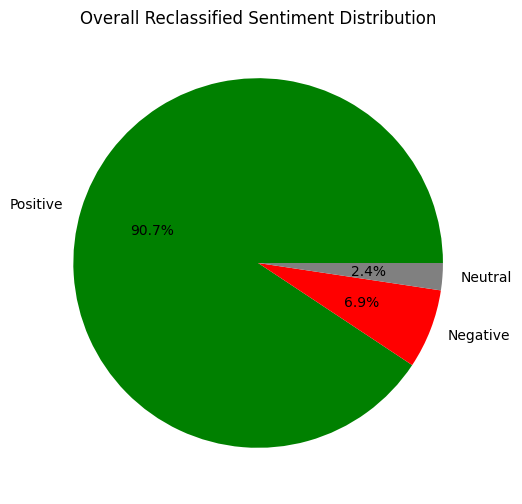

In [ ]:
import matplotlib.pyplot as plt

# Count the number of reviews per sentiment
sentiment_counts = df['Reclassified_Sentiment'].value_counts()

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct='%1.1f%%', colors=['green', 'red', 'gray'])
plt.title("Overall Reclassified Sentiment Distribution")
plt.show()

In [ ]:
# Cross-tabulation of Reclassified Ratings vs VADER Sentiment
comparison_table = pd.crosstab(df['Reclassified_Sentiment'], df['VADER_Sentiment'])

# Display comparison
print(comparison_table)


VADER_Sentiment         Negative  Neutral  Positive
Reclassified_Sentiment                             
Negative                    2263      457      1572
Neutral                      335      256       874
Positive                    1087     3641     51312


ACCURACY BETWEEN RECLASSIFIED SENTIMENT AND VADER SENTIMENT AND EXTBLOB

In [ ]:
from sklearn.metrics import accuracy_score

# Compute accuracy
accuracy1 = accuracy_score(df['Reclassified_Sentiment'], df['VADER_Sentiment'])
print(f"Accuracy BEtween Reclassified and VADER : {accuracy1:.4f}")

# Compute accuracy
accuracy2 = accuracy_score(df['Reclassified_Sentiment'], df['TextBlob_Sentiment'])
print(f"Accuracy BEtween Reclassified and VADER : {accuracy2:.4f}")

# Compute accuracy
accuracy3 = accuracy_score(df['TextBlob_Sentiment'], df['VADER_Sentiment'])
print(f"Accuracy BEtween TextBlob and VADER : {accuracy3:.4f}")



Accuracy BEtween Reclassified and VADER : 0.8711
Accuracy BEtween Reclassified and VADER : 0.8382
Accuracy BEtween TextBlob and VADER : 0.8537


In [ ]:
from sklearn.metrics import cohen_kappa_score

# Compute Cohen's Kappa score
kappa = cohen_kappa_score(df['Reclassified_Sentiment'], df['VADER_Sentiment'])
print(f"Between Reclassified and VADER using Cohen’s Kappa Score: {kappa:.4f}")


Between Reclassified and VADER using Cohen’s Kappa Score: 0.3722


In [ ]:
from sklearn.metrics import cohen_kappa_score

# Compute Cohen's Kappa score
kappa = cohen_kappa_score(df['Reclassified_Sentiment'], df['TextBlob_Sentiment'])
print(f"Agreement between Reclassified and Textblob Sntiment using Cohen’s Kappa Score: {kappa:.4f}")

Agreement between Reclassified and Textblob Sntiment using Cohen’s Kappa Score: 0.2848


In [ ]:
# Compute Cohen's Kappa score
kappa = cohen_kappa_score(df['VADER_Sentiment'], df['TextBlob_Sentiment'])
print(f"Agreement between Reclassified and Textblob Sntiment using Cohen’s Kappa Score: {kappa:.4f}")

Agreement between Reclassified and Textblob Sntiment using Cohen’s Kappa Score: 0.4229


**MODEL DVELOPMENT**'


This secion wil utilize VADER sentiment and Reclassification sentiment as the dependent variables to develop a SVM and RF model...

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report

# Convert categorical target variables to numeric labels
df['VADER_Label'] = df['VADER_Sentiment'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})
df['Reclassified_Label'] = df['Reclassified_Sentiment'].map({'Negative': 0, 'Neutral': 1, 'Positive': 2})

# Text feature extraction (TF-IDF)
vectorizer = TfidfVectorizer(max_features=5000)  # Limit features to reduce processing time
X = vectorizer.fit_transform(df['Cleaned_Review'])

In [ ]:
from sklearn.model_selection import train_test_split

# Split into train (70%), validation (15%), and test (15%)
X_train, X_temp, y_train_vader, y_temp_vader = train_test_split(X, df['VADER_Label'], test_size=0.3, random_state=42)
X_val, X_test, y_val_vader, y_test_vader = train_test_split(X_temp, y_temp_vader, test_size=0.5, random_state=42)

X_train, X_temp, y_train_reclass, y_temp_reclass = train_test_split(X, df['Reclassified_Label'], test_size=0.3, random_state=42)
X_val, X_test, y_val_reclass, y_test_reclass = train_test_split(X_temp, y_temp_reclass, test_size=0.5, random_state=42)

VADER SENTIMENT AS DEPENDENT VARIABLE

In [ ]:
# Initialize models
svm_model = SVC(kernel='linear', random_state=42)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train models on VADER sentiment
svm_model.fit(X_train, y_train_vader)
rf_model.fit(X_train, y_train_vader)

RandomForestClassifier(random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

#SVM Predictions on test set
svm_test_pred_vader = svm_model.predict(X_test)

#random forest prediction on test sets
rf_test_pred_vader = rf_model.predict(X_test)

# Evaluate models on VADER Sentiment
print("🔹 SVM Model (VADER)")
print(classification_report(y_test_vader, svm_test_pred_vader))
print("\n🔹 Random Forest Model (VADER)")
print(classification_report(y_test_vader, rf_test_pred_vader))


🔹 SVM Model (VADER)
              precision    recall  f1-score   support

           0       0.83      0.70      0.76       585
           1       0.86      0.86      0.86       665
           2       0.97      0.99      0.98      8020

    accuracy                           0.96      9270
   macro avg       0.89      0.85      0.87      9270
weighted avg       0.96      0.96      0.96      9270


🔹 Random Forest Model (VADER)
              precision    recall  f1-score   support

           0       0.85      0.41      0.55       585
           1       0.84      0.66      0.74       665
           2       0.94      0.99      0.96      8020

    accuracy                           0.93      9270
   macro avg       0.87      0.69      0.75      9270
weighted avg       0.92      0.93      0.92      9270



In [ ]:
#VAlidation
svm_val_pred_vader = svm_model.predict(X_val)
rf_val_pred_vader = rf_model.predict(X_val)

# Accuracy comparison
print("🔹 SVM Validation Accuracy (VADER):", accuracy_score(y_val_vader, svm_val_pred_vader))
print("🔹 SVM Test Accuracy (VADER):", accuracy_score(y_test_vader, svm_test_pred_vader))
print("🔹 RF Validation Accuracy (VADER):", accuracy_score(y_val_vader, rf_val_pred_vader))
print("🔹 RF Test Accuracy (VADER):", accuracy_score(y_test_vader, rf_test_pred_vader))

🔹 SVM Validation Accuracy (VADER): 0.9612729234088457
🔹 SVM Test Accuracy (VADER): 0.9581445523193096
🔹 RF Validation Accuracy (VADER): 0.9294498381877022
🔹 RF Test Accuracy (VADER): 0.9282632146709816


RECLASSIFIED SENTIMENT

In [ ]:
# Train models on Reclassified sentiment
svm_model_reclass = SVC(kernel='linear', random_state=42)
rf_model_reclass = RandomForestClassifier(n_estimators=100, random_state=42)

svm_model_reclass.fit(X_train, y_train_reclass)
rf_model_reclass.fit(X_train, y_train_reclass)

RandomForestClassifier(random_state=42)

In [ ]:
#svm on test reclassfied data
svm_test_pred_reclass = svm_model_reclass.predict(X_test)

#RF on test reclassified data
rf_test_pred_reclass = rf_model_reclass.predict(X_test)

# Evaluate models on Reclassified Sentiment
print("\n🔹 SVM Model (Reclassified Sentiment)")
print(classification_report(y_test_reclass, svm_test_pred_reclass))
print("\n🔹 Random Forest Model (Reclassified Sentiment)")
print(classification_report(y_test_reclass, rf_test_pred_reclass))





🔹 SVM Model (Reclassified Sentiment)
              precision    recall  f1-score   support

           0       0.85      0.76      0.80       658
           1       0.51      0.09      0.16       211
           2       0.97      0.99      0.98      8401

    accuracy                           0.96      9270
   macro avg       0.78      0.62      0.65      9270
weighted avg       0.95      0.96      0.95      9270


🔹 Random Forest Model (Reclassified Sentiment)
              precision    recall  f1-score   support

           0       0.88      0.55      0.67       658
           1       0.25      0.00      0.01       211
           2       0.95      1.00      0.97      8401

    accuracy                           0.94      9270
   macro avg       0.69      0.52      0.55      9270
weighted avg       0.92      0.94      0.93      9270



In [ ]:
#VALIDATION
svm_val_pred_reclass = svm_model_reclass.predict(X_val)

rf_val_pred_reclass = rf_model_reclass.predict(X_val)

print("\n🔹 SVM Validation Accuracy (Reclassified Sentiment):", accuracy_score(y_val_reclass, svm_val_pred_reclass))
print("🔹 SVM Test Accuracy (Reclassified Sentiment):", accuracy_score(y_test_reclass, svm_test_pred_reclass))
print("🔹 RF Validation Accuracy (Reclassified Sentiment):", accuracy_score(y_val_reclass, rf_val_pred_reclass))
print("🔹 RF Test Accuracy (Reclassified Sentiment):", accuracy_score(y_test_reclass, rf_test_pred_reclass))



🔹 SVM Validation Accuracy (Reclassified Sentiment): 0.9526429341963323
🔹 SVM Test Accuracy (Reclassified Sentiment): 0.9564185544768069
🔹 RF Validation Accuracy (Reclassified Sentiment): 0.9426105717367853
🔹 RF Test Accuracy (Reclassified Sentiment): 0.9420711974110032
